# Data

Data is perhaps the most important aspect of Structural Dynamics.  There are many different types of data that one may encounter in Structural Dynamics, from the simple time history tracking some quantity of interest over time, to more complex transfer functions, shock response spectra, or power spectral density matrices.  Data objects in SDynPy can be viewed as somewhat of a "work in progress", where commonly used data types such as time histories or transfer functions have a great deal of functionality defined for them, while less commonly used data types such as the correlation array have almost no specific functionality defined.  Generally, functionality is added as it is required to be used, and with the main authors of SDynPy primarily working in vibration and modal analysis fields, users will find that types of data used in these fields are more fleshed out with functionality.

<!-- 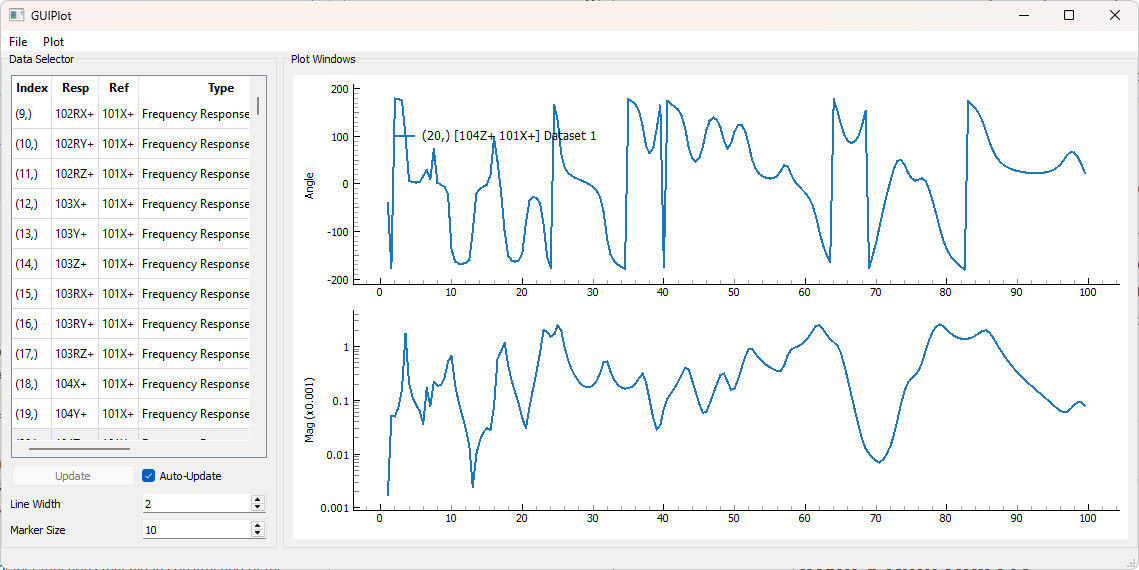 -->

:::{figure} attachment:8cb22c42-118f-4f4d-aeb6-b8cea22ba081.png

Example `GUIPlot` showing FRF data
:::

This document will demonstrate how data is defined and used in SDynPy.  It will document basic operations that can be performed on data.  Many SDynPy data objects also contain signal processing functionality; however, to reign in the scope of this document, signal processing operations will be discussed in later documentation.

Let's import SDynPy and start looking at Data!

In [1]:
import sdynpy as sdpy
import numpy as np

## SDynPy Data Objects

In order to provide commonality between all data objects in SDynPy while also providing the unique functionality that each data object requires, SDynPy users a inheritance-based model to define data objects.  The parent class of all data classes in SDynPy is the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) object.  As the name implies, this object inherits from and therefore has all of the functionality of the [`SdynpyArray`](xref:api#sdynpy.core.sdynpy_array.SdynpyArray) and therefore a NumPy ``ndarray``.  SDynPy then defines subclasses of the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) to represent specific data types; for example the [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) represents data over time, the [`PowerSpectralDensityArray`](xref:api#sdynpy.core.sdynpy_data.PowerSpectralDensityArray) represents power spectral density functions, and the [`TransferFunctionArray`](xref:api#sdynpy.core.sdynpy_data.TransferFunctionArray) represents transfer functions such as frequency response functions.  Given the variety of types of data that can be represented by the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) and its subclasses, the sizes and types of the field are flexible.  A time series represented by a [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) would generally consist of real data, whereas a frequency response function represented by a [`TransferFunctionArray`](xref:api#sdynpy.core.sdynpy_data.TransferFunctionArray) would generally consist of complex data.  Similarly a [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) may have a single degree of freedom (represented by a [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray)) associated with each piece of data; however a [`TransferFunctionArray`](xref:api#sdynpy.core.sdynpy_data.TransferFunctionArray) would generally have an input degree of freedom and an output degree of freedom associated with each piece of data.  We will explore these differences throughout this document.

Similar to other [`SdynpyArray`](xref:api#sdynpy.core.sdynpy_array.SdynpyArray) subclasses, the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) class and its subclasses have helper functions that aid in constructing of the objects.  These generally will have the same name, except with ``snake_case`` capitalization instead of the ``CamelCase`` capitalization of the class.  For example, a [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) object may be constructed with the [`time_history_array`](xref:api#sdynpy.core.sdynpy_data.time_history_array) function.  The exception to this rule is that there is not a specific helper function for the parent [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) class, as this parent class will typically not be used directly.

Let's start by creating a basic [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) object consisting of a sinusoidal signal.

In [2]:
num_sines = 10
frequencies = np.arange(num_sines)*10
timesteps = np.arange(1000)/1000
signal = np.sin(2*np.pi*frequencies[:,np.newaxis]*timesteps) # Will broadcast to a 10x1000 array
coordinate = sdpy.coordinate_array(1,'X+')

time_history = sdpy.time_history_array(
    abscissa = timesteps,
    ordinate = signal,
    coordinate = coordinate,
    comment1 = "A Comment",
    comment2 = "Another Comment",
    comment3 = "A Third Comment",
    comment4 = "A Fourth Comment",
    comment5 = "One Last Comment"
)

Note that when we create a [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) object such as this [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) object, we must define at a minimum the ``abscissa``, the ``ordinate``, and the ``coordinate``.  The ``abscissa`` are the independent variables; for a time history, this would be the value of time at each sample.  For a spectral quantity such as a frequency response function or a power spectral density function, this would be the frequency lines.  The ``ordinate`` field is then the dependent variable.  In the case of a time history, this would be the value of the function at each time step.  Note that when defining abscissa and ordinate, SDynPy does not handle units.  Users should ensure their data is in a consistent unit systems, because no conversions will be done by SDynPy.

Users must also assign degree of freedom information to each item in the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) using the ``coordinate`` argument.  These will be the standard SDynPy [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray) objects discussed previously in @sec:coordinates.

Finally, users can assign up to five comments for each item in the array.  These could be used to store any information pertinent to the analysis.  Units (g, m, m/s, N, etc.) or unit type (force, acceleration, etc.) may be valid information to store, but it is worth mentioning again: SDynPy will not attempt to parse these comments when doing any analysis on the data, and will not try to perform unit conversions for the user.

Now that we have a [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) subclass defined, let's look at some of its [`fields`](xref:api#sdynpy.core.sdynpy_data.DecayedSineTable.fields) and ``dtype``.

In [3]:
time_history.fields

('abscissa',
 'ordinate',
 'comment1',
 'comment2',
 'comment3',
 'comment4',
 'comment5',
 'coordinate')

In [4]:
time_history.dtype

dtype([('abscissa', '<f8', (1000,)), ('ordinate', '<f8', (1000,)), ('comment1', '<U80'), ('comment2', '<U80'), ('comment3', '<U80'), ('comment4', '<U80'), ('comment5', '<U80'), ('coordinate', [('node', '<u8'), ('direction', 'i1')], (1,))])

We can see the for each function in the [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray), we have floating point fields ``abscissa`` and ``ordinate``.  We can see that these fields have shape ``(1000,)``, which represents the 1000 time steps in our sine wave.

We also see the five comment fields, ``comment1`` through ``comment5``, which are strings.  The choice for five comment fields stems from the [Universal File Format](https://www.ceas3.uc.edu/sdrluff/) Dataset 58, which is used to store functions at nodal degrees of freedom.  Dataset 58 stores five ID Line records, and SDynPy objects typically try to match the corresponding Universal File Format object.

The last field is the ``coordinate`` field, and we note that this field has shape `(1,)`.  This means for that this object, there is one coordinate for each entry in the array.  We also see that the ``coordinate`` field is a compound ``dtype``, which contains ``node`` and ``direction`` fields.  Readers having read the @sec:coordinates will recognize this as the ``dtype`` of the [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray) object, meaning [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) objects store coordinate information as a [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray).

In [5]:
time_history.dtype['coordinate']

dtype(([('node', '<u8'), ('direction', 'i1')], (1,)))

In [6]:
# Create a dummy coordinate array so we can see its dtype
sdpy.coordinate_array(1,1).dtype

dtype([('node', '<u8'), ('direction', 'i1')])

Indeed, if we request the ``coordinate`` field of a [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) object, we will receive a [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray) object.

In [7]:
time_history.coordinate

coordinate_array(string_array=
array([['1X+'],
       ['1X+'],
       ['1X+'],
       ['1X+'],
       ['1X+'],
       ['1X+'],
       ['1X+'],
       ['1X+'],
       ['1X+'],
       ['1X+']], dtype='<U3'))

For comparison, let's create a [`TransferFunctionArray`](xref:api#sdynpy.core.sdynpy_data.TransferFunctionArray) object and compare its ``dtype``.

In [8]:
freqs = np.arange(1000)
ordinate = np.random.randn(1000)
coordinate = sdpy.coordinate_array([1,2],'X+') # Uses broadcasting
tf = sdpy.transfer_function_array(
    abscissa = freqs,
    ordinate = ordinate,
    coordinate = coordinate
)

tf.dtype

dtype([('abscissa', '<f8', (1000,)), ('ordinate', '<c16', (1000,)), ('comment1', '<U80'), ('comment2', '<U80'), ('comment3', '<U80'), ('comment4', '<U80'), ('comment5', '<U80'), ('coordinate', [('node', '<u8'), ('direction', 'i1')], (2,))])

We see that for this ``TransferFuntionArray``, the ``ordinate`` field is now a complex number ``<c16`` compared to a real number ``<f8`` like in the [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray).  Similarly, the shape of the ``coordinate`` ``dtype`` is now ``(2,)`` instead of ``(1,)``, meaning there are two coordinates for each of the transfer functions.

Recall from previous documentation that when a ``dtype`` has a shape associated with it, that shape will be appended to the end of the shape of the array itself.  For example, our sine time history currently has shape ``(10,)``

In [9]:
time_history.shape

(10,)

If we then look at the ``coordinate`` field, which has ``dtype`` with shape ``(1,)``, we should see its shape be ``(10,1)``.

In [10]:
time_history.coordinate.shape

(10, 1)

This can be a point of confusion when working with [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) subclasses, particularly with the subclasses that have ``coordinate`` fields with shape ``(1,)``.  Many users will forget to include this last dimension on the ``coordinate`` field.  This is particularly detrimental because NumPy will not broadcast the incorrect shape of ``(10,)`` to the correct shape of ``(10,1)``.  Per NumPy broadcasting rules, the ``(1,)`` dimension will be expanded to match the provided dimension, so the final shape will instead be ``(10,10)``, which will not be correct.

Similarly, we see that the ``abscissa`` and ``ordinate`` fields also have non-scalar ``dtype`` shapes of ``(1000,)``.  This means that these fields will have a shape of ``(10,1000)``.

In [11]:
time_history.ordinate.shape

(10, 1000)

## Creating Data from Scratch

Now that we have discusssed a bit about the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) object and its subclasses, let's look more closely at how we can construct one.  We will assume we have time history that are sines and cosines, and use that to create our data arrays.  Here we will pay more attention to the sizes of the arrays to demonstrate exactly how the functions work.

First, we will construct a multidimensional array of data that we will use for the ordinate.  We will try to end up with a 5 x 2 array of time histories, where each row corresponds to an increasing frequency, and the two columns correspond to sines and cosines (or 0 and 90 degree phases, respectively).  We will create 1000 time steps for each function from 0 to 1 (or rather, slightly less than 1 due to Python's open interval).

In [12]:
# We will use broadcasting to help us construct these arrays.
frequencies = ((np.arange(5)+1)*10)[:,np.newaxis,np.newaxis] # Frequency is the first dimension
phases = (np.arange(2)*np.pi/2)[:,np.newaxis] # Phase is the second dimension
timesteps = np.arange(1000)/1000 # Timestep is the last dimension.
signal_ordinate = np.sin(2*np.pi*frequencies*timesteps+phases) # 3D broadcasting occuring in this last function.

# Check the shape
signal_ordinate.shape

(5, 2, 1000)

We can see we have our 5 x 2 sine waves each with 1000 time steps.  When we construct a [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) using the [`time_history_array`](xref:api#sdynpy.core.sdynpy_data.time_history_array) function with this value as the ``ordinate`` argument, the [`time_history_array`](xref:api#sdynpy.core.sdynpy_data.time_history_array) function will peel off the last dimension (1000) to use as the shape of the ``ordinate`` dtype, and the remaining dimensions (5 x 2) will be used as the shape of the [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) itself.

We could also create a variable with shape ``(5,2,1000)`` to use as the ``abscissa`` argument.  However the helper functions generally use broadcasting across the arguments, so our current ``timesteps`` variable with shape ``(1000)`` will automatically be broadcast to the correct ``(5,2,1000)`` shape.  We do, however, need to construct the entry for the ``coordinate`` argument.  Recalling what we learned previously, we know that a [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) will have a ``coordinate`` field with ``dtype`` that has the shape of ``(1,)``, meaning there is one degree of freedom per function.  Knowing that our [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) will have shape ``(5,2)``, we should append the ``dtype`` shape to this value to get the necessary shape for our [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray), which is ``(5,2,1)``.  We can do this by creating a shape ``(5,2)`` [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray) then using ``np.newaxis`` to add the last dimension.

In [13]:
coordinates = sdpy.coordinate_array( # Use broadcasting to get 5x2
    np.arange(5)[:,np.newaxis]+1,    # Nodes have shape 5x1
    ['X+','Y+']                      # Directions have shape 2
    )[...,np.newaxis]                # Add the newaxis at the end

# Check the size
coordinates.shape

(5, 2, 1)

Now we can pass this information to the [`time_history_array`](xref:api#sdynpy.core.sdynpy_data.time_history_array) function to construct our [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) object.

In [14]:
time_histories = sdpy.time_history_array(
    abscissa = timesteps,
    ordinate = signal_ordinate,
    coordinate = coordinates
)

If we want to know more about our data, we can simply type its name into the terminal. 

In [15]:
time_histories

TimeHistoryArray with shape 5 x 2 and 1000 elements per function

Here it tells us the shape of our [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) object as well as how many timesteps are in it.

As a second example with a different shape, let's compute some transfer functions.  There will be some slight differences between this and the previous example: the ``ordinate`` field can be complex for a [`TransferFunctionArray`](xref:api#sdynpy.core.sdynpy_data.TransferFunctionArray) and the ``coordinate`` field will now have ``dtype`` with shape ``(2,)``.  Another difference is that the abscissa value is now frequency lines instead of time steps; however since SDynPy does not handle units, it will not know the difference if we pass our ``timesteps`` array from the previous example as the ``abscissa`` for the present example.

Let's start by producing a complex where we compute the sine of the arguments the real part and the cosine of the argument as the imaginary part.

In [16]:
# We will use broadcasting to help us construct these arrays.
frequencies = ((np.arange(5)+1)*10)[:,np.newaxis,np.newaxis] # Frequency is the first dimension
phases = (np.arange(2)*np.pi/2)[:,np.newaxis] # Phase is the second dimension
timesteps = np.arange(1000)/1000 # Timestep is the last dimension.
signal_ordinate = np.sin(2*np.pi*frequencies*timesteps+phases) + 1j*np.cos(2*np.pi*frequencies*timesteps+phases) # 3D broadcasting occuring in this last function.

# Check the shape
signal_ordinate.shape

(5, 2, 1000)

We will also need to compute a ``coordinate`` field with size ``(5,2,2)`` where the last ``2`` is due to the shape of the ``coordinate`` field's ``dtype``.   Here we will not use ``np.newaxis`` because the new axis we need must have length 2 instead of length 1.  We will instead rely entirely on broadcasting.

In [17]:
coordinates = sdpy.coordinate_array(            # Use broadcasting to get 5x2x2
    np.arange(5)[:,np.newaxis,np.newaxis]+1,    # Nodes have shape 5x1x1
    [['X+','Z+'],
     ['Y+','Z+']]                               # Directions have shape 2 x 2
    )

# Check the size
coordinates.shape

(5, 2, 2)

Let's then create the [`TransferFunctionArray`](xref:api#sdynpy.core.sdynpy_data.TransferFunctionArray) using the helper function [`transfer_function_array`](xref:api#sdynpy.core.sdynpy_data.transfer_function_array).

In [18]:
tfs = sdpy.transfer_function_array(
    abscissa = timesteps,
    ordinate = signal_ordinate,
    coordinate = coordinates
)

Again, we can type the name into the terminal to get more information.

In [19]:
tfs

TransferFunctionArray with shape 5 x 2 and 1000 elements per function

## Visualizing Data

Up to this point, we have simply trusted SDynPy that it created our data correctly.  However, we would often like to verify this is the case by visualizing the data.  All [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) subclasses have a ``plot`` method.  Some subsclasses override the parent class method to add their own functionality.  Let's start with the [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) object.

<Axes: >

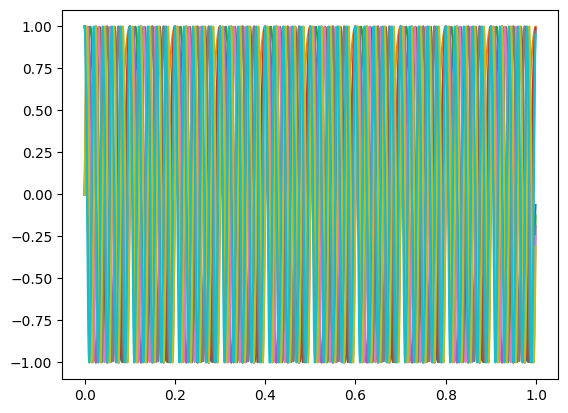

In [20]:
time_histories.plot()

We can see by simply calling the ``plot`` method, it has plotted all of the time histories on a single figure.  This may or may not be desirable.  If many functions are plotted, the plots may get busy and hard to read.  The ``one_axis`` argument of the function, which defaults to ``True`` can be set to ``False`` to plot all figures on separate plots.

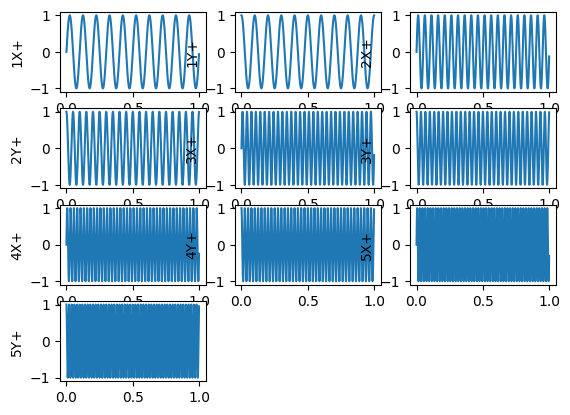

In [21]:
time_histories.plot(one_axis=False);

This may also produce varying levels of success depending on how many plots are plotted on the figure.  Note in the above, the axis labels overlay the adjacent plots.  To accomodate this, the ``plot`` method also takes optional arguments to allow us to customize the result and make it look more appealing.  These arguments are generally keyword arguments to the lower level Matplotlib function calls.

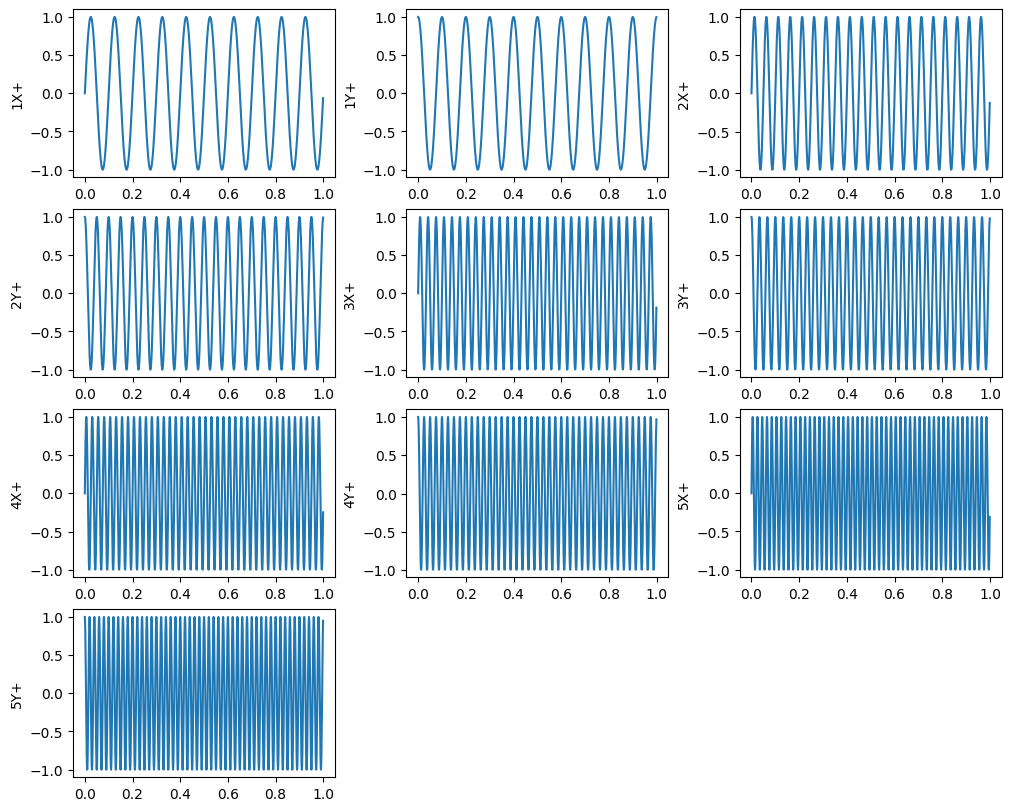

In [22]:
time_histories.plot(one_axis=False,subplots_kwargs={'layout':'constrained','figsize':(10,8)});

For certain types of data, the ``plot`` method is overridden to provide more appropriate functionality.  For example, our [`TransferFunctionArray`](xref:api#sdynpy.core.sdynpy_data.TransferFunctionArray) is a complex number.  If we simply ``plot`` it, we will see magnitude and phase.  Note that since we build our functions with the real part as a sine and the complex part as the cosine, the magnitude will be identically 1 while the phase changes with frequency.

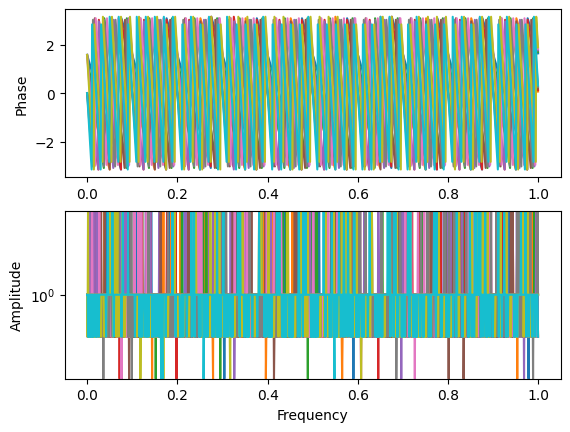

In [23]:
tfs.plot();

If we plot on multiple axes, we can see that it will by default plot the magnitude of the transfer function.

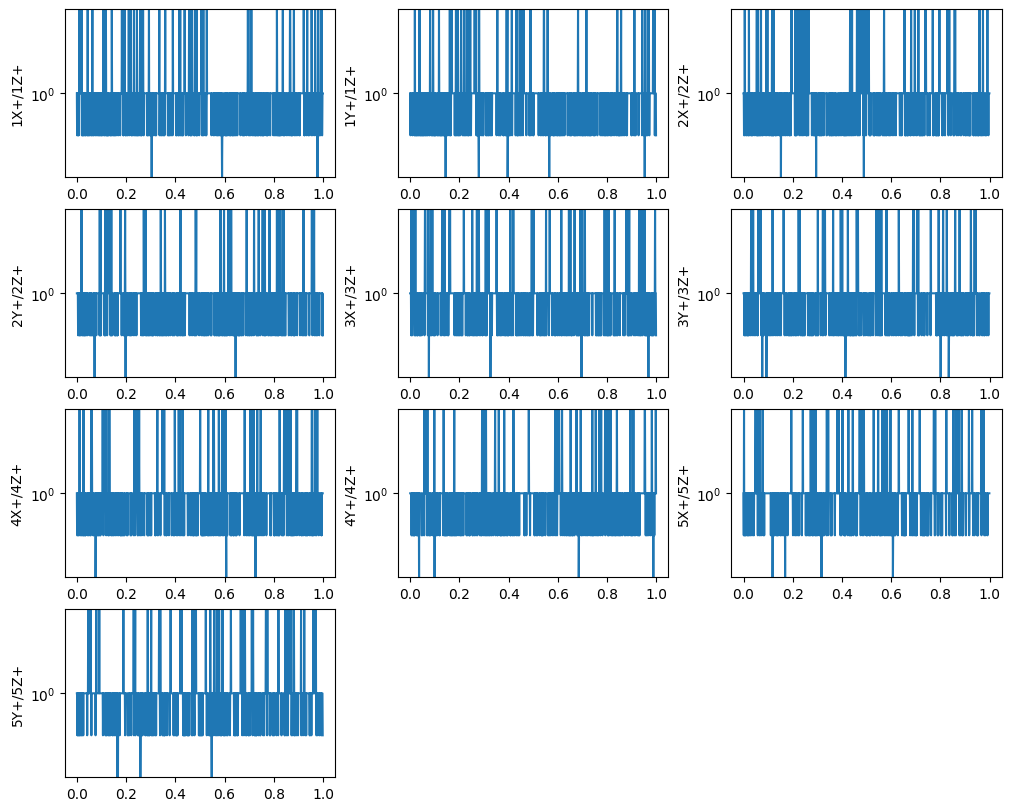

In [24]:
tfs.plot(one_axis=False,subplots_kwargs={'layout':'constrained','figsize':(10,8)});

However, we can specify which part of the [`TransferFunctionArray`](xref:api#sdynpy.core.sdynpy_data.TransferFunctionArray) to plot using the ``part`` argument.

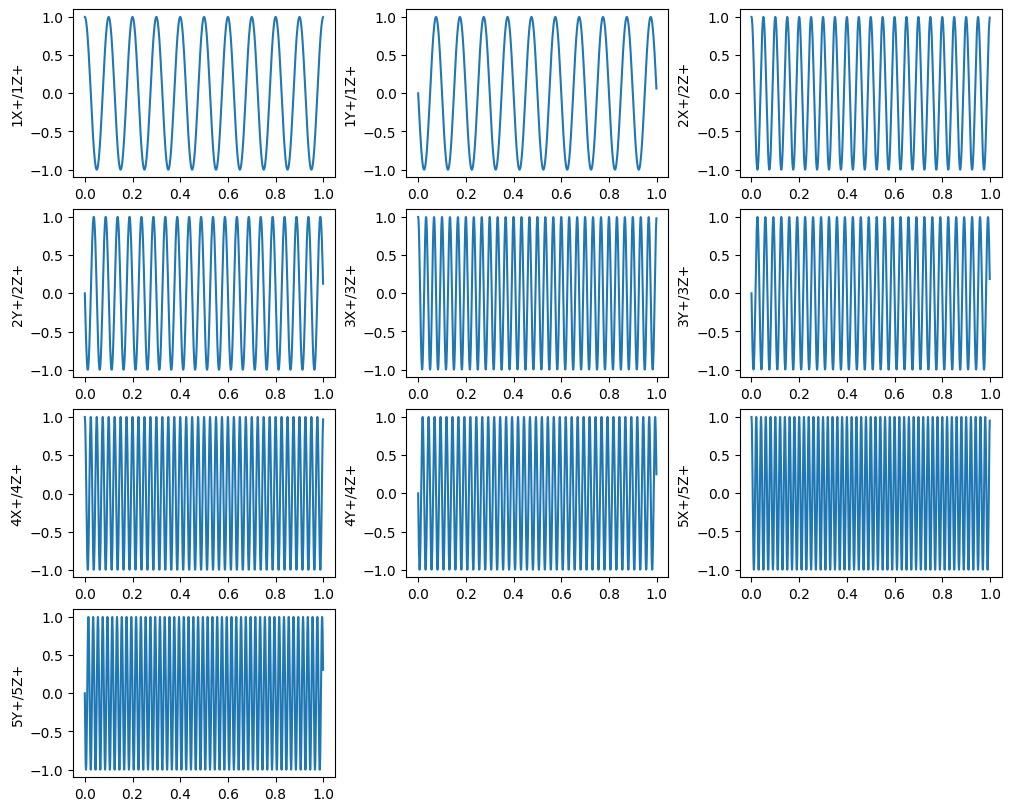

In [25]:
tfs.plot(one_axis=False,subplots_kwargs={'layout':'constrained','figsize':(10,8)},part='imag');

While the typical ``plot`` method allows you easily visualize moderately-sized datasets, as datasets grow larger, it can be difficult to put all of the data on one screen at once.  In this case, it might be easier to interactively explore the data.  SDynPy's [`GUIPlot`](xref:api#sdynpy.core.sdynpy_data.GUIPlot) capability will bring up a graphical user interface window in which the user will be presented with all of the functions that are available.  The user can then click on one or more of these functions to visualize.  To quickly bring up a [`GUIPlot`](xref:api#sdynpy.core.sdynpy_data.GUIPlot) window, users can call the [`gui_plot`](xref:api#sdynpy.core.sdynpy_data.NDDataArray.gui_plot) method.

Within this window, users can select the functions to plot from the table on the left.  The line width of the plots and sizes of markers (if used) can be adjusted.  The plot window on the right can be interactively zoomed to visualize certain portions of the plot.

In [26]:
time_histories.gui_plot()

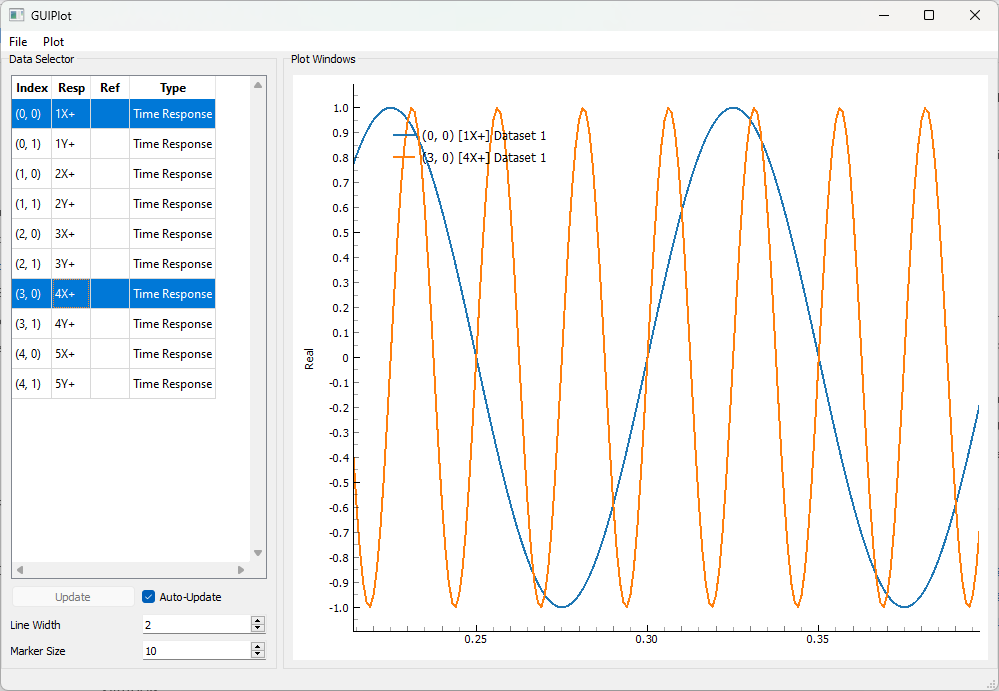


For more functionality, including the ability to compare different datasets, the [`GUIPlot`](xref:api#sdynpy.core.sdynpy_data.GUIPlot) class can be called directly.  Different datasets can be passed in as arguments or keyword arguments (in the latter case, the keyword labels will be used as the legend entries).  Additionally markers at specific times can be plotted with different styles.  See the documentation of [`GUIPlot`](xref:api#sdynpy.core.sdynpy_data.GUIPlot) for the full range of capabilities.

In [27]:
sdpy.GUIPlot(Sines = time_histories[:,0],Cosines = time_histories[:,1],
             abscissa_markers = [0,0.25,0.5],
             abscissa_marker_labels = ['0','1/4','1/2'],
             abscissa_marker_type = 'vline')

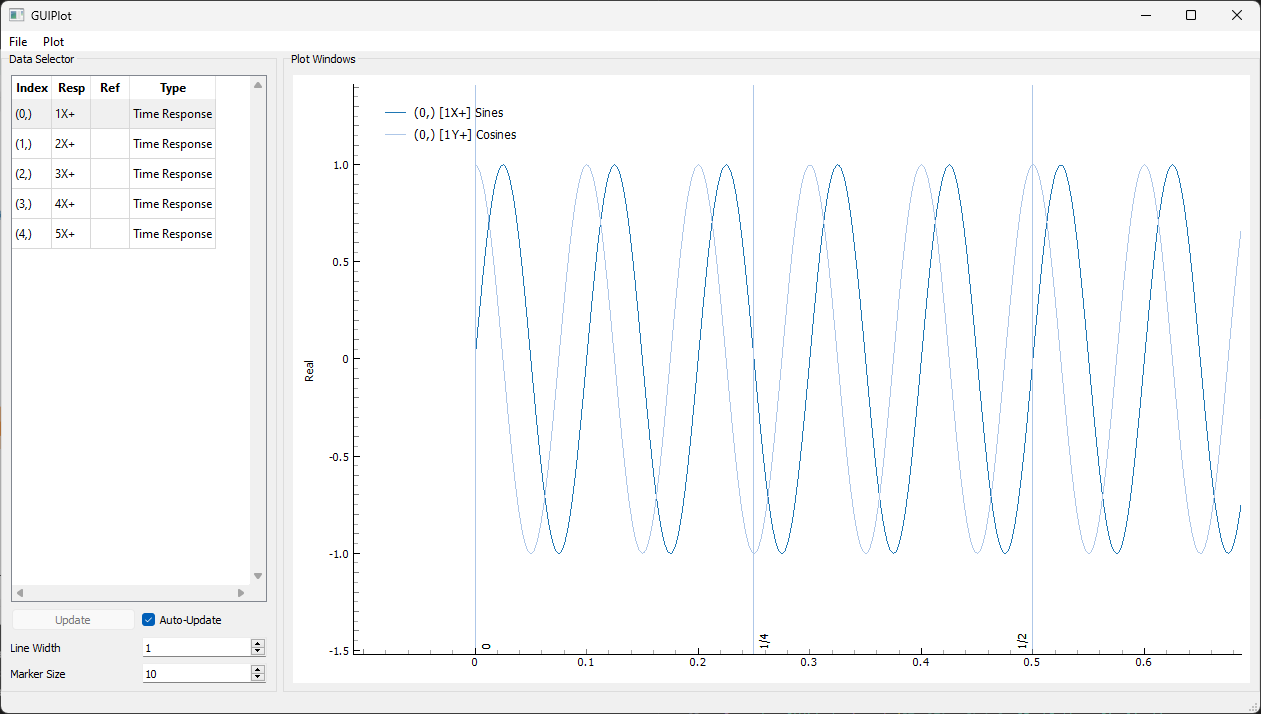

For complex data types, the [`GUIPlot`](xref:api#sdynpy.core.sdynpy_data.GUIPlot) can change how the complex values are presented (real/imaginary/magnitude/phase).  As well as whether or not the plot should use logarithmic scaling on each axis.

In [28]:
tfs.gui_plot()

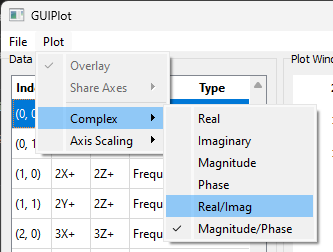

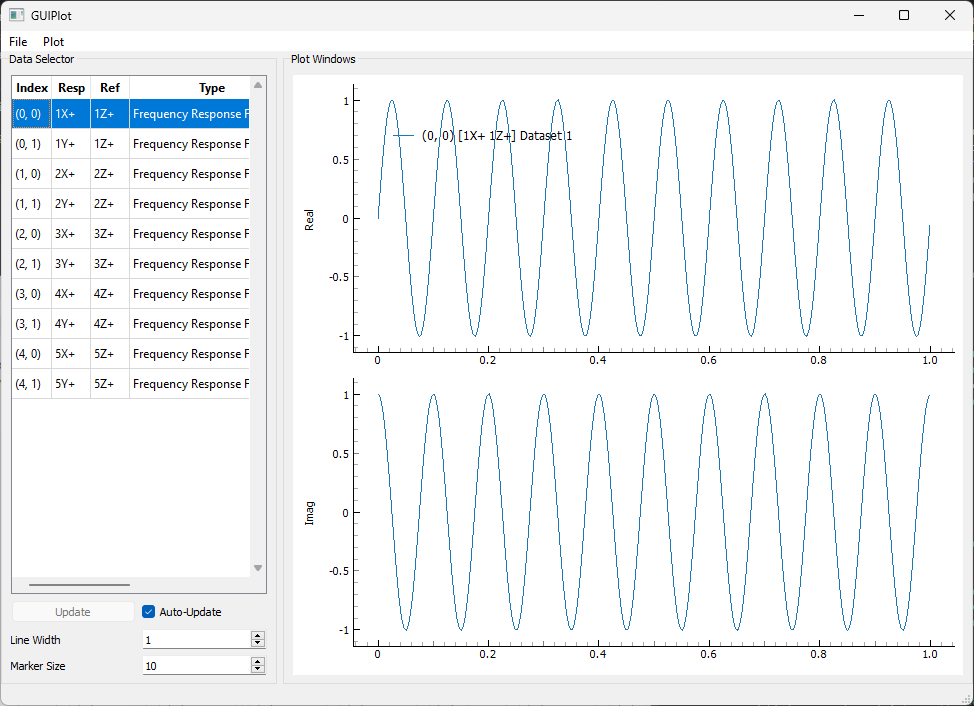

## Indexing NDDataArrays

In Structural Dynamics, we often would like to select specific pieces of data on which operations will be performed.  Because [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) objects are NumPy arrays, indexing is performed the same way on both [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) objects and NumPy arrays.

In [29]:
time_histories

TimeHistoryArray with shape 5 x 2 and 1000 elements per function

In [30]:
time_histories[2,1]

TimeHistoryArray with shape  and 1000 elements per function

In [31]:
time_histories[0,:]

TimeHistoryArray with shape 2 and 1000 elements per function

In [32]:
time_histories[[0,3,4],[0,1,0]]

TimeHistoryArray with shape 3 and 1000 elements per function

While standard NumPy indexing can be used successfully, it can be error-prone.  Often, one is looking for a specific degree of freedom, and using NumPy indexing, one must first find the index corresponding to that degree of freedom.

In [33]:
# Define the coordinate we are looking for
desired_dof = sdpy.coordinate_array(1,'X+')

# Recall coordinate field is ... x 1, so this is why we do all across
# the last axis.
dof_matches = np.all(time_histories.coordinate == desired_dof,axis=-1)

print('Matching Coordinates:')
print(dof_matches)

# Select the time history with that coordinate
matching_time_history = time_histories[dof_matches]

print('\nFound Time History: ')
print(matching_time_history)
print('With Coordinate:')
print(matching_time_history.coordinate)

Matching Coordinates:
[[ True False]
 [False False]
 [False False]
 [False False]
 [False False]]

Found Time History: 
TimeHistoryArray with shape 1 and 1000 elements per function
With Coordinate:
[['1X+']]


This is passable; however it is many lines of code for a single operation.  Additionally, it does not generalize well to more interesting circumstances.  For example, what if we wanted to find the time history associated with the ``1X-`` direction?

In [34]:
# Define the coordinate we are looking for
desired_dof = sdpy.coordinate_array(1,'X-')

# Recall coordinate field is ... x 1, so this is why we do all across
# the last axis.
dof_matches = np.all(time_histories.coordinate == desired_dof,axis=-1)

print('Matching Coordinates:')
print(dof_matches)

# Select the time history with that coordinate
matching_time_history = time_histories[dof_matches]

print('\nFound Time History: ')
print(matching_time_history)
print('With Coordinate:')
print(matching_time_history.coordinate)

Matching Coordinates:
[[False False]
 [False False]
 [False False]
 [False False]
 [False False]]

Found Time History: 
TimeHistoryArray with shape 0 and 1000 elements per function
With Coordinate:
[]


We now get no matches, even though we should be able to match the same function but just flip the sign on the function.  To handle this common occurrance in a more user-friendly way, SDynPy allows users to index [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) objects directly with a [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray) object.  SDynPy will then select the functions that match the coordinates for each coordinate.  This will accomodate sign flips and multidimensionality as well.

One important point to remember is that the shape of the ``coordinate`` field of the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) must be respected.  This means when selecting for [`TimeHistoryArray`](xref:api#sdynpy.core.sdynpy_data.TimeHistoryArray) objects, the [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray) should have shape ``(...,1)`` or for [`TransferFunctionArray`](xref:api#sdynpy.core.sdynpy_data.TransferFunctionArray) objects, the [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray) should have shape ``(...,2)``, where then ``...`` will be the shape of the output [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray).

In [35]:
# This has shape (3,))
desired_dofs = sdpy.coordinate_array([1,3,4],'X+')

# If we don't make it (3,1), the indexing operation will fail
time_histories[desired_dofs]

ValueError: Coordinate ['1X+' '3X+' '4X+'] not found in data array

In [36]:
# If we make it (3,1), then it will succeed
desired_dofs = desired_dofs[:,np.newaxis]
time_histories[desired_dofs].coordinate

coordinate_array(string_array=
array([['1X+'],
       ['3X+'],
       ['4X+']], dtype='<U3'))

As stated previously, this operation handles multidimensionality and sign flipping.  Let's set up an indexing operation that will pull the desired degrees of freedom while also exercising multidimensionality and sign flipping.

In [37]:
desired_dofs = sdpy.coordinate_array(
    [[3],[1],[4]], # 3x1
    ['X+','X-'],   # 1x2 (implicitly)
)[...,np.newaxis]  # add newaxis for 3x2x1

# We should get a 3x2 array, where the second column
# is the first column with the sign flipped.
desired_time_histories = time_histories[desired_dofs]

print(desired_time_histories)
print(desired_time_histories.coordinate)

TimeHistoryArray with shape 3 x 2 and 1000 elements per function
[[['3X+']
  ['3X-']]

 [['1X+']
  ['1X-']]

 [['4X+']
  ['4X-']]]


If we plot the functions, we should see that the different sign on the coordinate automatically flips the sign on the data as well.  We can also see that we have received the data in the same order as we requested it.  This enables very powerful indexing operations to be performed with minimal chance for bookkeeping errors.

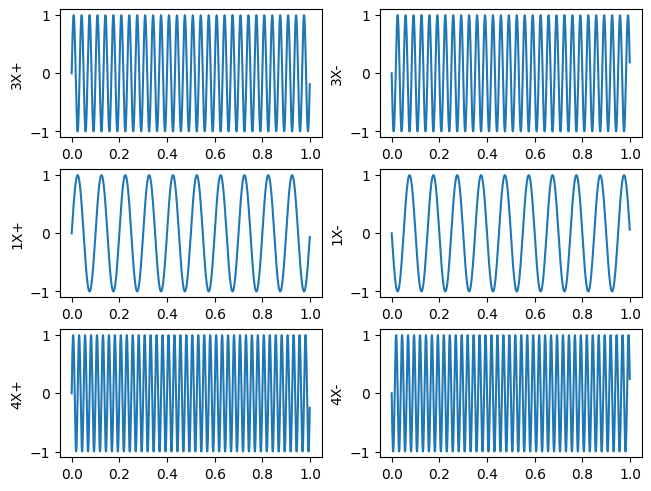

In [38]:
desired_time_histories.plot(one_axis=False,subplots_kwargs={'layout':'constrained'});

## Reading and Writing to NumPy Files

SDynPy does not have a native storage format for its data types.  However, being built mostly on NumPy arrays, it is almost trivial to use NumPy format for storage.  A [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) object can be saved using its [`NDDataArray.save`](xref:api#sdynpy.core.sdynpy_data.NDDataArray.save) method.  It will be written to a NumPy ``.npz`` file containing the equivalent NumPy structured array.  One additional field will be saved in the ``.npz`` file, which is subclass of the array.  Since the fields of each [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) are identical across types, the subclass of the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) could not be reconstructed from the field names alone.  Therefore, SDynPy must save this property in order to load it back in correctly.

In [39]:
time_histories.save('time_histories.npz')

To load a [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) object from the file, one can simply call the class method [`NDDataArray.load`](xref:api#sdynpy.core.sdynpy_data.NDDataArray.load) or its alias ``data.load``, which will recognize the subclass within the file and correctly reconstruct the object.

In [40]:
# Class method
time_histories_from_npz = sdpy.NDDataArray.load('time_histories.npz')
# Equivalent module-level alias
time_histories_from_npz = sdpy.data.load('time_histories.npz')

## Writing to Matlab Files

Many structural dynamicists utilize the Matlab programming language to perform structural dynamics analysis.  Therefore, it is useful to be able to share data between SDynPy and Matlab.  SDynPy can save data in a [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) to a ``.mat`` file using the [`savemat`](xref:api#sdynpy.core.sdynpy_array.SdynpyArray.savemat) method. 

In [41]:
time_histories.savemat('time_histories.mat')

The ``.mat`` file will contain fields with the same names and shapes as the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) object.  The ``coordinate`` field will be saved a a structure with node and direction fields.

In [42]:
from scipy.io import loadmat
time_history_matlab_data = loadmat('time_histories.mat')

time_history_matlab_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'abscissa', 'ordinate', 'comment1', 'comment2', 'comment3', 'comment4', 'comment5', 'coordinate'])

Because a ``.mat`` file can have any format, there is no dedicated [`loadmat`](xref:api#scipy.io.matlab._mio.loadmat) equivalent to [`savemat`](xref:api#sdynpy.core.sdynpy_array.SdynpyArray.savemat).  Since ``.mat`` files may have any field names, it is up to the user to open up the ``.mat`` file using their tool of choice, parse out the data required to construct a [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) object, and create the object manually from the underlying data.

## Summary

In summary, the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) object in SDynPy is used to store data information.  Many different types of data can be represented in SDynPy, and each of these is represented as a subclass of [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray).

The [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) objects store independent and dependent variables in ``abscissa`` and ``ordinate`` fields.  The degree of freedom information is stored simultaneously in a [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray) object that is the shape of the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) with the shape of the ``coordinate`` field itself appended.  This is because different types of data might be associated with different numbers of degrees of freedom.  A time history, for example, will have one degree of freedom associated with it.  A frequency response function, however, will have an input and an output degree of freedom associated with each function.

[`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) objects (or its subclasses) can be plotted easily with the ``plot`` method, which also accepts numerous arguments to customize the generated figure.  However, if many functions are to be plotted, it may be easier to interactively interrogate the data with [`GUIPlot`](xref:api#sdynpy.core.sdynpy_data.GUIPlot).  [`GUIPlot`](xref:api#sdynpy.core.sdynpy_data.GUIPlot) is well suited to compare data and apply annotations as well.


[`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) objects (or its subclasses) can be indexed using standard NumPy indexing operations.  However, they can also be indexed using [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray) objects.  These objects can be multidimensional or contain direction flips compared to the underlying data.  SDynPy will gracefully return the item corresponding to the requested [`CoordinateArray`](xref:api#sdynpy.core.sdynpy_coordinate.CoordinateArray) in the shape and order requested with any sign flips applied.

[`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) objects (or its subclasses) can be saved and loaded to disk in NumPy format as ``.npz`` files.  It is also straightforward to write the data to a Matlab ``.mat`` file.

This document has only scratched the surface of the functionality available in the [`NDDataArray`](xref:api#sdynpy.core.sdynpy_data.NDDataArray) class and its subclasses.  A large number of signal processing methods are available.  These methods will require full knowledge of SDynPy's core capabilities, and will be addressed in subsequent documentation.